# Particle Filter for Jump-Diffusion Models

**Notebook 2 of 3** - Application of the particle filter to financial
returns generated by a jump-diffusion process.

We work with the discrete-time **Merton (1976)** jump-diffusion:

$$
r_t \;=\; \mu \;+\; \sigma\,\varepsilon_t \;+\; J_t\,Z_t,
\qquad \varepsilon_t \sim \mathcal{N}(0,1),\;
J_t \sim \mathrm{Bern}(\lambda),\;
Z_t \sim \mathcal{N}(\mu_J, \sigma_J^2).
$$

The latent variables are the binary jump indicator $J_t$ and the jump size
$Z_t$.  A particle filter (here the Auxiliary PF of Pitt and Shephard) is
well suited to detect the discrete jumps and to compute the posterior
probability $\mathbb{P}(J_t = 1\mid r_{1:t})$.

We close with extensions to the **Kou (2002)** double-exponential model
and to the **Bates (1996)** stochastic-volatility-with-jumps model.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import logsumexp
from scipy.stats import norm

from particlefilterbox.core.config import PFConfig
from particlefilterbox.core.model import ParticleFilterModel
from particlefilterbox.filters import AuxiliaryPF

rng_seed = 20260422
DATA_DIR = Path('..') / 'data'
df = pd.read_csv(DATA_DIR / 'simulated_jump_diff.csv')
df.head()

,t,returns,jump_true,jump_size_true
0,0,0.003547,0,-0.0
1,1,-0.009900,0,-0.0
2,2,0.008005,0,-0.0
3,3,0.009906,0,0.0
4,4,-0.019010,0,-0.0


## 1. The Merton model in state-space form

The state vector is $x_t = (J_t, Z_t)$ where $J_t\in\{0,1\}$ flags a jump
and $Z_t$ is the (continuous) jump size.  The transition is iid:

$$
J_t \sim \mathrm{Bernoulli}(\lambda),
\qquad Z_t \sim \mathcal{N}(\mu_J,\sigma_J^2).
$$

The observation density is
$$
p(r_t\mid J_t,Z_t) = \mathcal{N}(r_t\mid \mu + J_t Z_t,\; \sigma^2).
$$

We use the data-generating parameters
($\mu=5\!\times\!10^{-4}$, $\sigma=0.01$, $\lambda=0.05$,
$\mu_J=-0.02$, $\sigma_J=0.03$).

In [2]:
class MertonJumpDiffusion(ParticleFilterModel):
    """State (jump_indicator, jump_size); iid in time."""

    k_states = 2
    k_obs = 1

    def __init__(self, mu=0.0005, sigma=0.01, lam=0.05, mu_j=-0.02, sigma_j=0.03):
        self.mu = float(mu); self.sigma = float(sigma); self.lam = float(lam)
        self.mu_j = float(mu_j); self.sigma_j = float(sigma_j)

    @property
    def params(self):
        return {'mu': self.mu, 'sigma': self.sigma, 'lam': self.lam,
                'mu_j': self.mu_j, 'sigma_j': self.sigma_j}

    def initial_distribution(self, n_particles, rng):
        J0 = rng.binomial(1, self.lam, size=n_particles).astype(float)
        Z0 = rng.normal(self.mu_j, self.sigma_j, size=n_particles)
        return np.column_stack([J0, J0 * Z0])

    def transition(self, particles, t, rng):
        n = particles.shape[0]
        J = rng.binomial(1, self.lam, size=n).astype(float)
        Z = rng.normal(self.mu_j, self.sigma_j, size=n)
        return np.column_stack([J, J * Z])

    def transition_mean(self, particles, t):
        # Expected next state: E[J] = lam, E[J*Z] = lam*mu_j
        n = particles.shape[0]
        return np.column_stack([np.full(n, self.lam), np.full(n, self.lam * self.mu_j)])

    def log_observation_likelihood(self, particles, y_t, t):
        r = float(np.asarray(y_t).ravel()[0])
        mean = self.mu + particles[:, 1]
        return norm.logpdf(r, loc=mean, scale=self.sigma)

model = MertonJumpDiffusion()
model.params

{'mu': 0.0005, 'sigma': 0.01, 'lam': 0.05, 'mu_j': -0.02, 'sigma_j': 0.03}

## 2. Run the Auxiliary Particle Filter

The Auxiliary PF (Pitt and Shephard, 1999) is well suited here because
the observation likelihood is sharply peaked when a jump occurs - the
lookahead step focuses particles on the relevant region of the state
space.  We use $N=1000$ particles.

In [3]:
y = df['returns'].to_numpy(dtype=float)
config = PFConfig(n_particles=1000, resampling='systematic', ess_threshold=0.5,
                  seed=rng_seed, store_particles=True, store_weights=True)
apf = AuxiliaryPF(model=model, config=config)
result = apf.filter(y)

print(f'log-likelihood : {result.log_likelihood:.2f}')
print(f'mean ESS       : {result.ess_history.mean():.1f}')

log-likelihood : 118.19
mean ESS       : 956.5


## 3. Posterior probability of a jump

The first state component $J_t$ is binary, so the weighted mean of the
filtered cloud is the posterior probability that a jump occurred at $t$:
$\widehat p_t = \mathbb{E}[J_t\mid r_{1:t}]$.  Because the cloud history
was stored, we can recover the $\widehat p_t$ trajectory exactly.

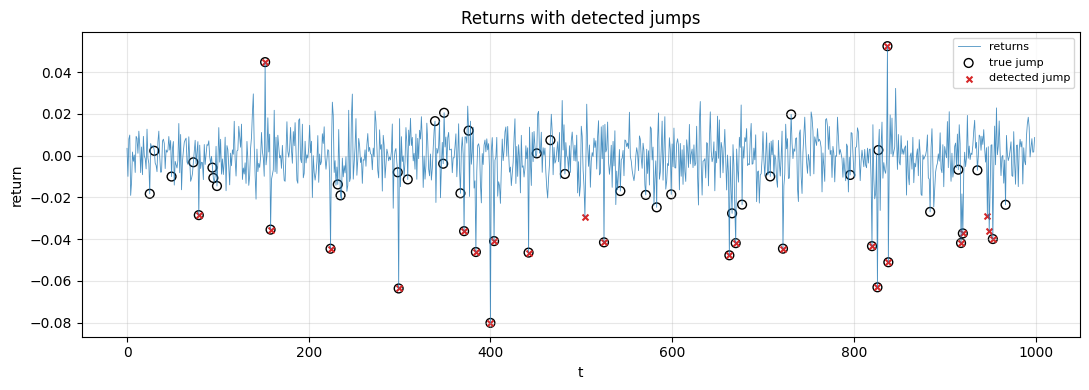

In [4]:
p_jump = result.filtered_means[:, 0]
z_hat = result.filtered_means[:, 1]
T = len(y)
t_axis = df['t'].to_numpy()

# Threshold for declaring a jump.
threshold = 0.5
jump_pred = (p_jump > threshold).astype(int)
jump_true = df['jump_true'].to_numpy()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_axis, y, color='C0', lw=0.6, alpha=0.8, label='returns')
true_idx = np.where(jump_true == 1)[0]
pred_idx = np.where(jump_pred == 1)[0]
ax.scatter(t_axis[true_idx], y[true_idx], s=40, marker='o',
           facecolors='none', edgecolors='black', lw=1.0, label='true jump')
ax.scatter(t_axis[pred_idx], y[pred_idx], s=18, marker='x',
           color='C3', label='detected jump')
ax.set_title('Returns with detected jumps'); ax.set_xlabel('t')
ax.set_ylabel('return'); ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

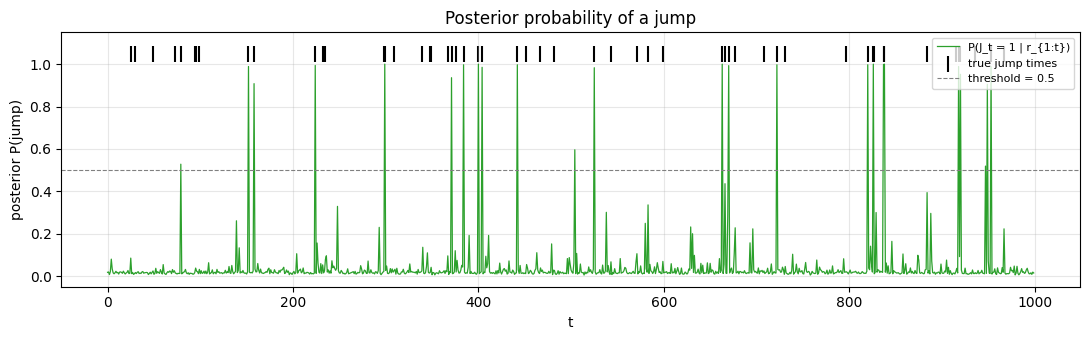

In [5]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_axis, p_jump, color='C2', lw=0.9, label='P(J_t = 1 | r_{1:t})')
ax.scatter(t_axis[true_idx], np.full_like(true_idx, 1.05, dtype=float),
           color='black', marker='|', s=120, label='true jump times')
ax.axhline(threshold, color='gray', ls='--', lw=0.8, label='threshold = 0.5')
ax.set_ylim(-0.05, 1.15); ax.set_xlabel('t'); ax.set_ylabel('posterior P(jump)')
ax.set_title('Posterior probability of a jump'); ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.show()

## 4. Detection performance

Treating jump detection as a binary classification problem, we report
**precision** (share of declared jumps that were real) and **recall**
(share of real jumps that were detected) at the 0.5 threshold.

In [6]:
def precision_recall(y_true, y_pred):
    tp = int(np.sum((y_pred == 1) & (y_true == 1)))
    fp = int(np.sum((y_pred == 1) & (y_true == 0)))
    fn = int(np.sum((y_pred == 0) & (y_true == 1)))
    tn = int(np.sum((y_pred == 0) & (y_true == 0)))
    precision = tp / max(tp + fp, 1)
    recall    = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)
    return tp, fp, fn, tn, precision, recall, f1

tp, fp, fn, tn, prec, rec, f1 = precision_recall(jump_true, jump_pred)
summary = pd.DataFrame({
    'metric': ['true positives', 'false positives', 'false negatives',
               'true negatives', 'precision', 'recall', 'F1'],
    'value':  [tp, fp, fn, tn, round(prec, 3), round(rec, 3), round(f1, 3)],
})
summary

,metric,value
0,true positives,21.000
1,false positives,3.000
2,false negatives,33.000
3,true negatives,943.000
4,precision,0.875
5,recall,0.389
6,F1,0.538


## 5. Extension - Kou's double-exponential jumps

Merton jumps are symmetric Gaussian.  **Kou (2002)** replaces $Z_t$ with
an asymmetric double-exponential (Laplace) distribution to allow heavier
and asymmetric tails:

$$
f_Z(z) = p\,\eta_1 e^{-\eta_1 z}\mathbf{1}_{z\ge 0}
      \;+\;(1-p)\,\eta_2 e^{\eta_2 z}\mathbf{1}_{z<0},
$$

with $p\in[0,1]$, $\eta_1>1$, $\eta_2>0$.  Switching to Kou inside the
particle filter only requires changing `transition`: sample $J_t$ as
before and draw $Z_t$ from the double-exponential density.  All other
code (filter, weighting, plots) stays identical.

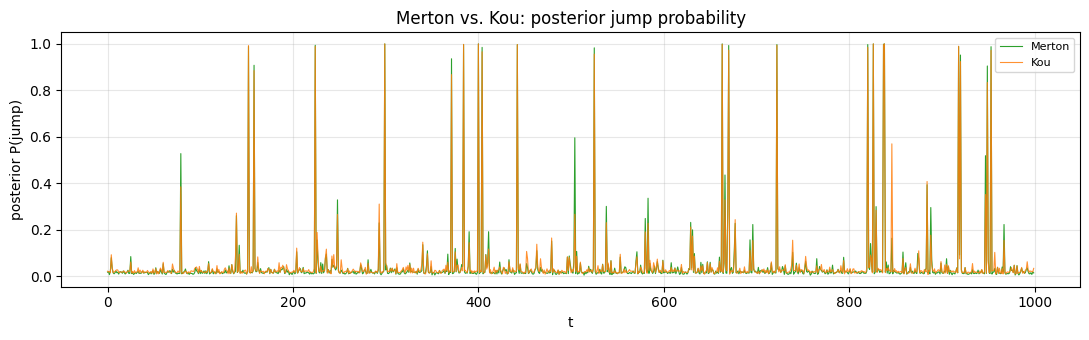

In [7]:
class KouJumpDiffusion(MertonJumpDiffusion):
    def __init__(self, mu=0.0005, sigma=0.01, lam=0.05,
                 p_up=0.4, eta1=40.0, eta2=30.0):
        super().__init__(mu=mu, sigma=sigma, lam=lam)
        self.p_up = float(p_up); self.eta1 = float(eta1); self.eta2 = float(eta2)

    def _sample_kou(self, n, rng):
        up = rng.uniform(size=n) < self.p_up
        z = np.where(up,
                     rng.exponential(1.0 / self.eta1, size=n),
                     -rng.exponential(1.0 / self.eta2, size=n))
        return z

    def transition(self, particles, t, rng):
        n = particles.shape[0]
        J = rng.binomial(1, self.lam, size=n).astype(float)
        Z = self._sample_kou(n, rng)
        return np.column_stack([J, J * Z])

kou = KouJumpDiffusion()
kou_pf = AuxiliaryPF(model=kou, config=PFConfig(n_particles=1000, seed=rng_seed))
kou_res = kou_pf.filter(y)
p_jump_kou = kou_res.filtered_means[:, 0]

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_axis, p_jump, color='C2', lw=0.8, label='Merton')
ax.plot(t_axis, p_jump_kou, color='C1', lw=0.8, alpha=0.85, label='Kou')
ax.set_xlabel('t'); ax.set_ylabel('posterior P(jump)')
ax.set_title('Merton vs. Kou: posterior jump probability')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 6. Bates (SV + jumps)

The Bates (1996) model adds stochastic volatility on top of the
jump-diffusion:

$$
r_t = \mu + e^{h_t/2}\,\varepsilon_t + J_t Z_t,\qquad
h_t = \mu_h + \phi_h(h_{t-1}-\mu_h) + \sigma_h\,\eta_t.
$$

The state vector enlarges to $(h_t, J_t, Z_t)$.  This is a textbook
particle-filter problem because the joint smoother is intractable in
closed form.  In `particlefilterbox` we would only need to write a new
`ParticleFilterModel` that combines the AR(1) log-volatility update with
the Bernoulli-Gaussian jump used here, and reuse `AuxiliaryPF` or the
Rao-Blackwellised filter to integrate out $Z_t$ analytically.

## 7. Conclusion

* Particle filters handle models with **discontinuities** (jumps) without
  any modification to the algorithm.
* The Auxiliary PF is a natural choice because it focuses particles where
  the likelihood is sharp.
* The same `ParticleFilterModel` interface scales from Merton to Kou and
  Bates with very few lines of code, illustrating the modularity of the
  library.